# Oz-Speller-style plots for the two FBTDCA training runs

This notebook reproduces the intent of the plots referenced at Oz-Speller README lines 207, 251, and 253. It shows onset-aligned Oz averages and class templates before and after the learned FBTDCA/TDCA spatial filter, with run 1 and run 2 overlaid.

In [1]:
from collections import defaultdict
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import yaml
from brainda.algorithms.decomposition.dsp import xiang_dsp_feature
from brainda.algorithms.decomposition.tdca import aug_2
from scipy import signal

from ssvep_bci.training import load_fbtdca_dataset
from ssvep_bci.training.fbtdca import (
    _extract_epoch, _load_numeric_csv, _pair_events, _read_events,
)

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "ssvep-bci" / "pyproject.toml").is_file():
            return candidate
        if (candidate / "src" / "ssvep_bci").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the BCI repository root")

REPO_ROOT = find_repo_root()
PARTICIPANT_ID = "mike_a"
SESSION_PATHS = [
    REPO_ROOT / "ssvep-bci/sessions/20260801T192258Z_mike_a_fbtdca-run-1_a299483b",
    REPO_ROOT / "ssvep-bci/sessions/20260801T193028Z_mike_a_fbtdca-run-2_f940ff62",
]
RUN_LABELS = ["Run 1", "Run 2"]
MODEL_PATH = REPO_ROOT / "ssvep-bci/models/mike_a/four_frequency_fbtdca_2s.joblib"
OUTPUT_DIR = REPO_ROOT / "ssvep-bci/reports/figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
dataset = load_fbtdca_dataset(
    SESSION_PATHS, PARTICIPANT_ID,
    window_onset_offset_seconds=0.25,
    window_length_seconds=2.0,
)
artifact = joblib.load(MODEL_PATH)
model = artifact["estimator"]
metadata = artifact["metadata"]
if metadata["participant_id"] != PARTICIPANT_ID:
    raise ValueError("Model participant does not match the plotted sessions")
if metadata["window_onset_offset_seconds"] != 0.25 or metadata["window_length_seconds"] != 2.0:
    raise ValueError("This notebook expects the cut 2-second FBTDCA model")
frequencies = dataset.candidate_frequencies_hz
rate = dataset.sampling_rate_hz
oz_index = dataset.channel_names.index("Oz")
print("Sessions:", [path.name for path in dataset.session_paths])
print("Dataset shape:", dataset.eeg.shape)
print("Frequencies:", frequencies)

Sessions: ['20260801T192258Z_mike_a_fbtdca-run-1_a299483b', '20260801T193028Z_mike_a_fbtdca-run-2_f940ff62']
Dataset shape: (96, 8, 500)
Frequencies: (8.0, 9.0, 13.0, 14.0)


## Onset-aligned Oz averages (Oz-Speller README line 207)

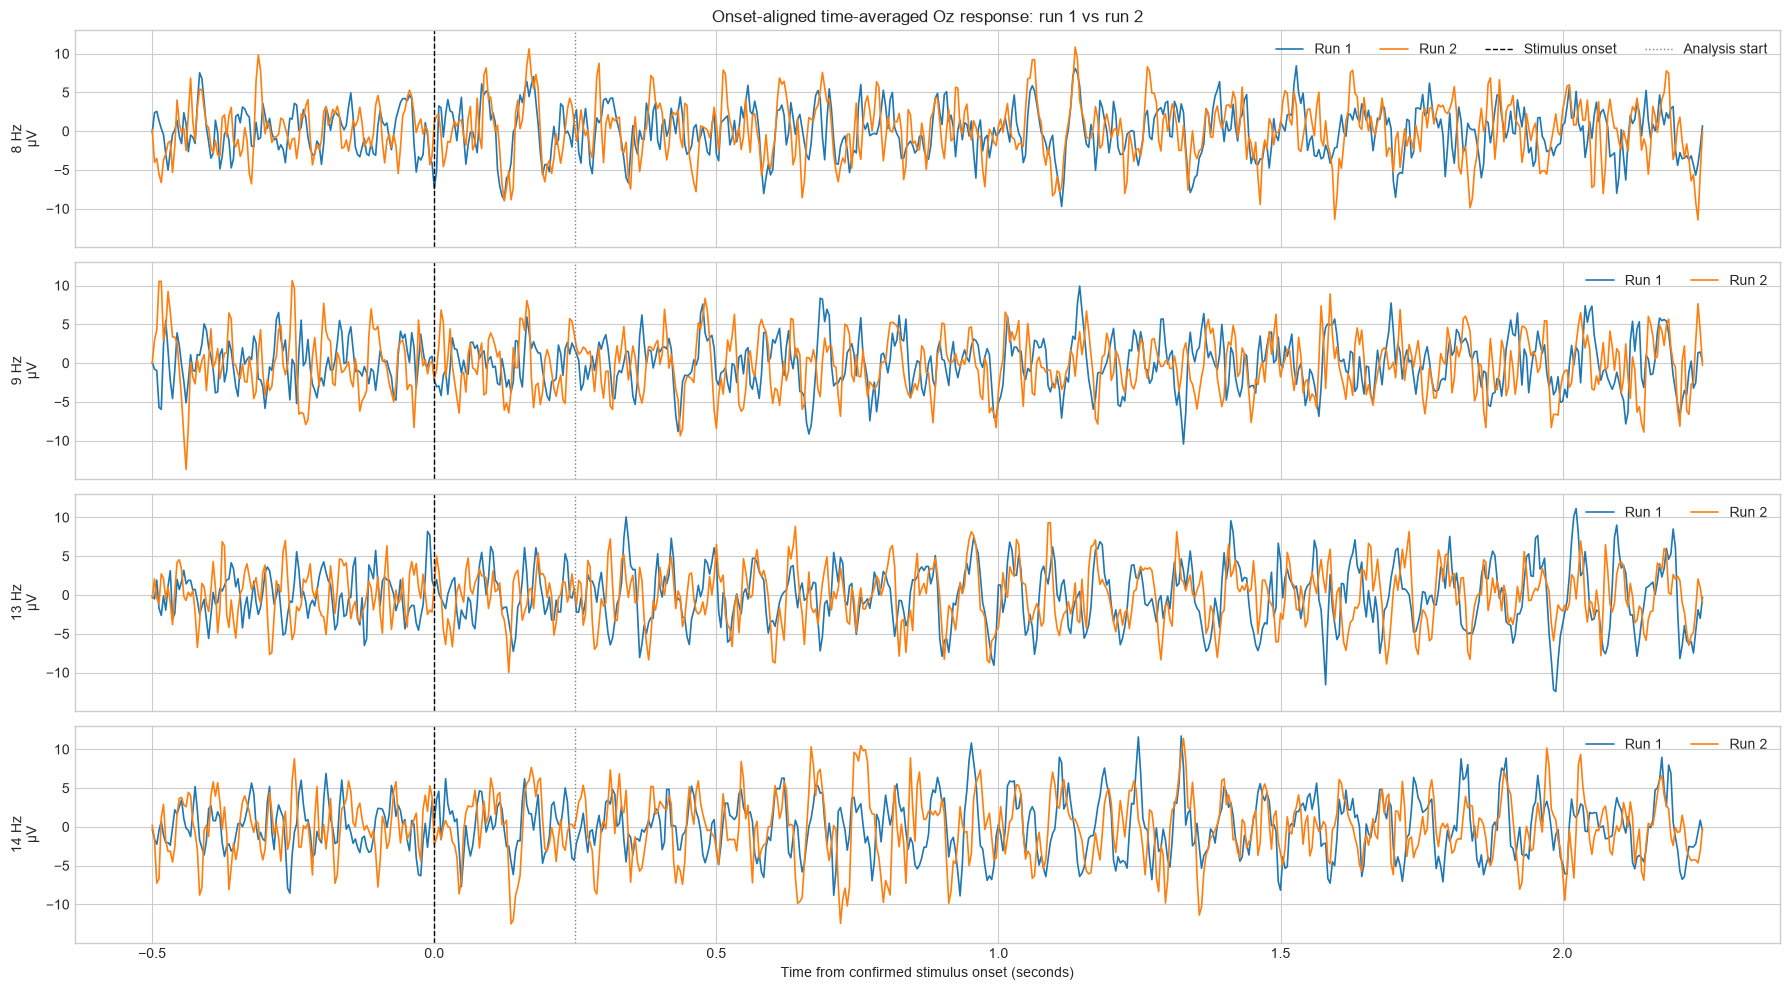

Saved: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\reports\figures\mike_a_fbtdca_runs_onset_average.png


In [3]:
pre_onset_seconds = 0.5
post_onset_seconds = 2.25
onset_sample_count = round((pre_onset_seconds + post_onset_seconds) * rate)
onset_time_seconds = np.arange(onset_sample_count) / rate - pre_onset_seconds
onset_averages = {}

for run_index, session_path in enumerate(SESSION_PATHS):
    experiment = yaml.safe_load((session_path / "experiment-config.yaml").read_text(encoding="utf-8"))
    stimulus_frequencies = {
        str(item["id"]): float(item["frequency_hz"])
        for item in experiment["stimuli"]
    }
    timestamps, raw_eeg = _load_numeric_csv(session_path / "eeg_raw.csv", dataset.channel_names)
    pairs = _pair_events(_read_events(session_path / "events.jsonl"), stimulus_frequencies)
    notch_b, notch_a = signal.iirnotch(
        dataset.notch_frequency_hz, dataset.notch_quality_factor, rate
    )
    epochs_by_frequency = defaultdict(list)
    for pair in pairs:
        epoch = _extract_epoch(
            timestamps, raw_eeg, pair["onset"] - pre_onset_seconds,
            pre_onset_seconds + post_onset_seconds, onset_sample_count,
        )
        if epoch is None:
            raise RuntimeError(f"Incomplete onset plot epoch: {pair['presentation_id']}")
        epoch = signal.filtfilt(notch_b, notch_a, epoch, axis=-1)
        epoch = signal.sosfiltfilt(model.filterbank[0], epoch, axis=-1)
        baseline_samples = round(pre_onset_seconds * rate)
        epoch = epoch - epoch[:, :baseline_samples].mean(axis=-1, keepdims=True)
        epochs_by_frequency[pair["frequency_hz"]].append(epoch[oz_index])
    for frequency in frequencies:
        onset_averages[(run_index, frequency)] = np.mean(epochs_by_frequency[frequency], axis=0)

fig, axes = plt.subplots(len(frequencies), 1, figsize=(18, 10), sharex=True, sharey=True)
for class_index, (ax, frequency) in enumerate(zip(axes, frequencies, strict=True)):
    for run_index, run_label in enumerate(RUN_LABELS):
        ax.plot(onset_time_seconds, onset_averages[(run_index, frequency)], label=run_label, linewidth=1.2)
    ax.axvline(0.0, linestyle="--", color="black", linewidth=1, label="Stimulus onset" if class_index == 0 else None)
    ax.axvline(0.25, linestyle=":", color="gray", linewidth=1, label="Analysis start" if class_index == 0 else None)
    ax.set_ylabel(f"{frequency:g} Hz\nµV")
    ax.legend(loc="upper right", ncols=4)
axes[0].set_title("Onset-aligned time-averaged Oz response: run 1 vs run 2")
axes[-1].set_xlabel("Time from confirmed stimulus onset (seconds)")
fig.tight_layout()
onset_path = OUTPUT_DIR / "mike_a_fbtdca_runs_onset_average.png"
fig.savefig(onset_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", onset_path)

## Before the learned spatial filter, after temporal filter-bank band 1 (Oz-Speller README line 251)

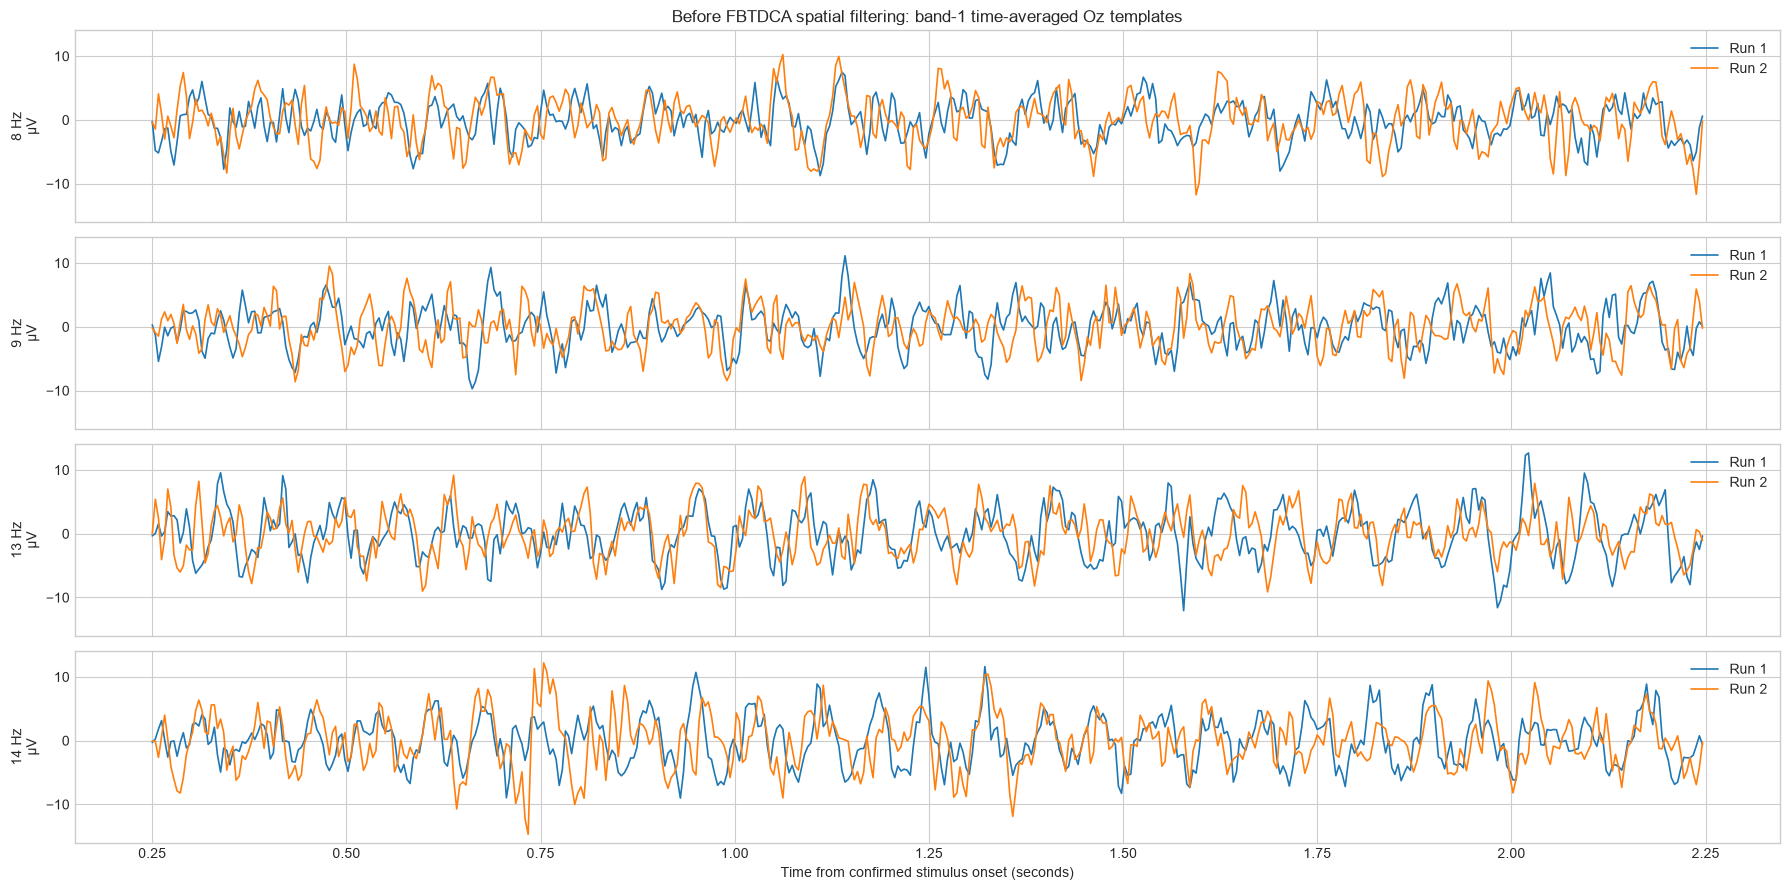

Saved: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\reports\figures\mike_a_fbtdca_runs_before_spatial_filter.png


In [4]:
centered_eeg = dataset.eeg - dataset.eeg.mean(axis=-1, keepdims=True)
first_band_eeg = signal.sosfiltfilt(model.filterbank[0], centered_eeg, axis=-1)
analysis_time_seconds = dataset.window_onset_offset_seconds + np.arange(dataset.eeg.shape[-1]) / rate
fig, axes = plt.subplots(len(frequencies), 1, figsize=(18, 9), sharex=True, sharey=True)
for class_index, (ax, frequency) in enumerate(zip(axes, frequencies, strict=True)):
    for run_index, run_label in enumerate(RUN_LABELS):
        selection = (dataset.session_groups == run_index) & (dataset.labels == class_index)
        raw_template = first_band_eeg[selection, oz_index, :].mean(axis=0)
        ax.plot(analysis_time_seconds, raw_template, label=run_label, linewidth=1.2)
    ax.set_ylabel(f"{frequency:g} Hz\nµV")
    ax.legend(loc="upper right")
axes[0].set_title("Before FBTDCA spatial filtering: band-1 time-averaged Oz templates")
axes[-1].set_xlabel("Time from confirmed stimulus onset (seconds)")
fig.tight_layout()
before_path = OUTPUT_DIR / "mike_a_fbtdca_runs_before_spatial_filter.png"
fig.savefig(before_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", before_path)

## After the learned FBTDCA/TDCA spatial filter (Oz-Speller README line 253)

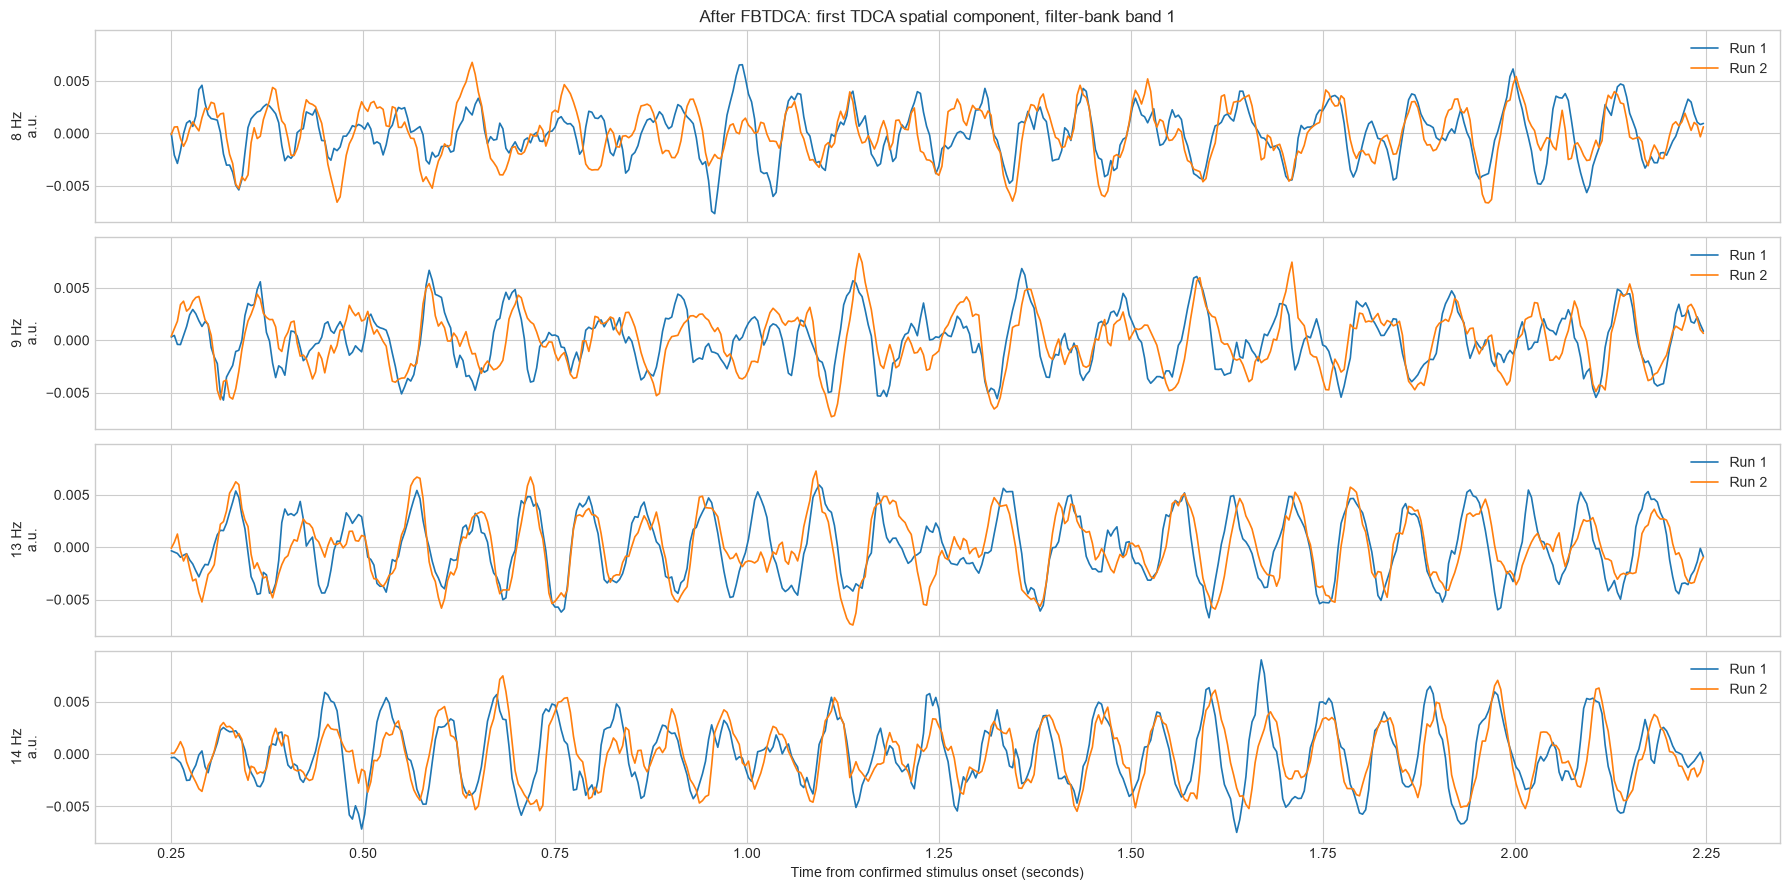

Saved: C:\Users\MykhailoAntropov\IdeaProjects\turiba\BCI\ssvep-bci\reports\figures\mike_a_fbtdca_runs_after_spatial_filter.png


In [5]:
first_band_tdca = model.estimators_[0]
fig, axes = plt.subplots(len(frequencies), 1, figsize=(18, 9), sharex=True, sharey=True)
for class_index, (ax, frequency) in enumerate(zip(axes, frequencies, strict=True)):
    projection = first_band_tdca.Ps_[class_index]
    for run_index, run_label in enumerate(RUN_LABELS):
        selection = (dataset.session_groups == run_index) & (dataset.labels == class_index)
        augmented = aug_2(
            first_band_eeg[selection], projection.shape[0],
            first_band_tdca.l, projection, training=True,
        )
        components = xiang_dsp_feature(
            first_band_tdca.W_, first_band_tdca.M_, augmented, n_components=1
        )
        filtered_template = components[:, 0, :dataset.eeg.shape[-1]].mean(axis=0)
        ax.plot(analysis_time_seconds, filtered_template, label=run_label, linewidth=1.2)
    ax.set_ylabel(f"{frequency:g} Hz\na.u.")
    ax.legend(loc="upper right")
axes[0].set_title("After FBTDCA: first TDCA spatial component, filter-bank band 1")
axes[-1].set_xlabel("Time from confirmed stimulus onset (seconds)")
fig.tight_layout()
after_path = OUTPUT_DIR / "mike_a_fbtdca_runs_after_spatial_filter.png"
fig.savefig(after_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", after_path)